<a href="https://colab.research.google.com/github/GaeloHerrera/country-size-income-per-capita-regression/blob/main/TP1/RISK_MANAGEMENT_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch the data.
df1 = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.metadata.json?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019").json()


df2 = pd.read_csv("https://ourworldindata.org/grapher/population.csv?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/population.metadata.json?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019").json()


df3 = pd.read_csv("https://ourworldindata.org/grapher/share-of-population-urban.csv?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/share-of-population-urban.metadata.json?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019").json()

df4 = pd.read_csv("https://ourworldindata.org/grapher/life-expectancy.csv?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/life-expectancy.metadata.json?v=1&csvType=filtered&useColumnShortNames=false&tab=table&time=2019").json()

In [ ]:
df1

,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia
...,...,...,...,...,...
7235,Zimbabwe,ZWE,2020,4527.7197,Africa
7236,Zimbabwe,ZWE,2021,4827.0890,Africa
7237,Zimbabwe,ZWE,2022,5036.7610,Africa
7238,Zimbabwe,ZWE,2023,5218.0225,Africa


In [ ]:
df1_2019 = df1[df1['Year'] == 2019].copy()
df1_2019

,Entity,Code,Year,GDP per capita,World region according to OWID
19,Afghanistan,AFG,2019,2927.2450,Asia
53,Albania,ALB,2019,16761.1930,Europe
88,Algeria,DZA,2019,15199.1990,Africa
123,Andorra,AND,2019,63215.9000,Europe
158,Angola,AGO,2019,9648.0110,Africa
...,...,...,...,...,...
7094,Vanuatu,VUT,2019,3512.0720,Oceania
7129,Vietnam,VNM,2019,11628.6140,Asia
7164,World,OWID_WRL,2019,19552.0840,NaN
7199,Zambia,ZMB,2019,3591.5642,Africa


In [ ]:
df2_2019 = df2[df2['Year'] == 2019].copy()
df2_2019

,Entity,Code,Year,Population
256,Afghanistan,AFG,2019,37856125
517,Africa,NaN,2019,1348005692
591,Africa (UN),NaN,2019,1348005494
855,Albania,ALB,2019,2885011
1116,Algeria,DZA,2019,43294551
...,...,...,...,...
57652,Western Sahara,ESH,2019,538450
57913,World,OWID_WRL,2019,7811293699
58174,Yemen,YEM,2019,35111416
58558,Zambia,ZMB,2019,18513839


In [ ]:
df3_2019 = df3[df3['Year'] == 2019].copy()
df3_2019

,Entity,Code,Year,Urban population (% of total population)
59,Afghanistan,AFG,2019,25.143726
124,Albania,ALB,2019,56.763910
189,Algeria,DZA,2019,72.482450
254,American Samoa,ASM,2019,83.054214
319,Andorra,AND,2019,88.539180
...,...,...,...,...
14684,Vietnam,VNM,2019,34.623913
14749,World,OWID_WRL,2019,56.139400
14814,Yemen,YEM,2019,34.906757
14879,Zambia,ZMB,2019,43.489788


In [ ]:
df4_2019 = df4[df4['Year'] == 2019].copy()
df4_2019

,Entity,Code,Year,Life expectancy
69,Afghanistan,AFG,2019,62.9411
145,Africa,NaN,2019,62.4490
219,Albania,ALB,2019,79.4669
296,Algeria,DZA,2019,75.6818
370,American Samoa,ASM,2019,72.7511
...,...,...,...,...
21257,Western Sahara,ESH,2019,70.3822
21338,World,OWID_WRL,2019,72.6093
21412,Yemen,YEM,2019,66.5673
21486,Zambia,ZMB,2019,62.9145


In [ ]:
### UNION THE 3 DATA FRAMES ###
df_final = pd.merge(df1_2019, df2_2019.drop(columns=['Year']), on=['Entity', 'Code'])
df_final = pd.merge(df_final, df3_2019.drop(columns=['Year']), on=['Entity', 'Code'])
df_final = pd.merge(df_final, df4_2019.drop(columns=['Year']), on=['Entity', 'Code'])

In [ ]:
df_final = df_final.dropna()
df_final

,Entity,Code,Year,GDP per capita,World region according to OWID,Population,Urban population (% of total population),Life expectancy
0,Afghanistan,AFG,2019,2927.2450,Asia,37856125,25.143726,62.9411
1,Albania,ALB,2019,16761.1930,Europe,2885011,56.763910,79.4669
2,Algeria,DZA,2019,15199.1990,Africa,43294551,72.482450,75.6818
3,Andorra,AND,2019,63215.9000,Europe,76492,88.539180,84.0980
4,Angola,AGO,2019,9648.0110,Africa,32375633,66.663780,63.0511
...,...,...,...,...,...,...,...,...
194,Uzbekistan,UZB,2019,8755.1260,Asia,32964700,50.592010,72.0934
195,Vanuatu,VUT,2019,3512.0720,Oceania,291995,23.502466,70.7834
196,Vietnam,VNM,2019,11628.6140,Asia,97173778,34.623913,74.2113
198,Zambia,ZMB,2019,3591.5642,Africa,18513839,43.489788,62.9145


In [ ]:
df_final.head()

,Entity,Code,Year,GDP per capita,World region according to OWID,Population,Urban population (% of total population),Life expectancy
0,Afghanistan,AFG,2019,2927.245,Asia,37856125,25.143726,62.9411
1,Albania,ALB,2019,16761.193,Europe,2885011,56.763910,79.4669
2,Algeria,DZA,2019,15199.199,Africa,43294551,72.482450,75.6818
3,Andorra,AND,2019,63215.900,Europe,76492,88.539180,84.0980
4,Angola,AGO,2019,9648.011,Africa,32375633,66.663780,63.0511


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Entity                                    199 non-null    object 
 1   Code                                      199 non-null    object 
 2   Year                                      199 non-null    int64  
 3   GDP per capita                            199 non-null    float64
 4   World region according to OWID            199 non-null    object 
 5   Population                                199 non-null    int64  
 6   Urban population (% of total population)  199 non-null    float64
 7   Life expectancy                           199 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 14.0+ KB


In [ ]:
df_final.describe()

,Year,GDP per capita,Population,Urban population (% of total population),Life expectancy
count,199.0,199.000000,1.990000e+02,199.000000,199.000000
mean,2019.0,26305.484065,3.853559e+07,61.255540,72.639930
std,0.0,26223.851145,1.460296e+08,23.126610,7.941055
min,2019.0,1057.950100,1.060300e+04,13.927827,31.530200
25%,2019.0,6337.483350,1.313884e+06,42.591521,66.868800
50%,2019.0,16761.193000,6.966155e+06,62.709915,73.668100
75%,2019.0,38237.003500,2.684955e+07,79.606490,78.260550
max,2019.0,133453.890000,1.423520e+09,100.000000,85.263200


In [ ]:
df_final["Entity"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Estonia', 'Eswatini',
       'Ethiopia', 'Faroe Islands', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',

In [ ]:
### APPLY LN ##

df_final["ln_gdp"] = np.log(df_final["GDP per capita"])
df_final['ln_pop'] = np.log(df_final["Population"])

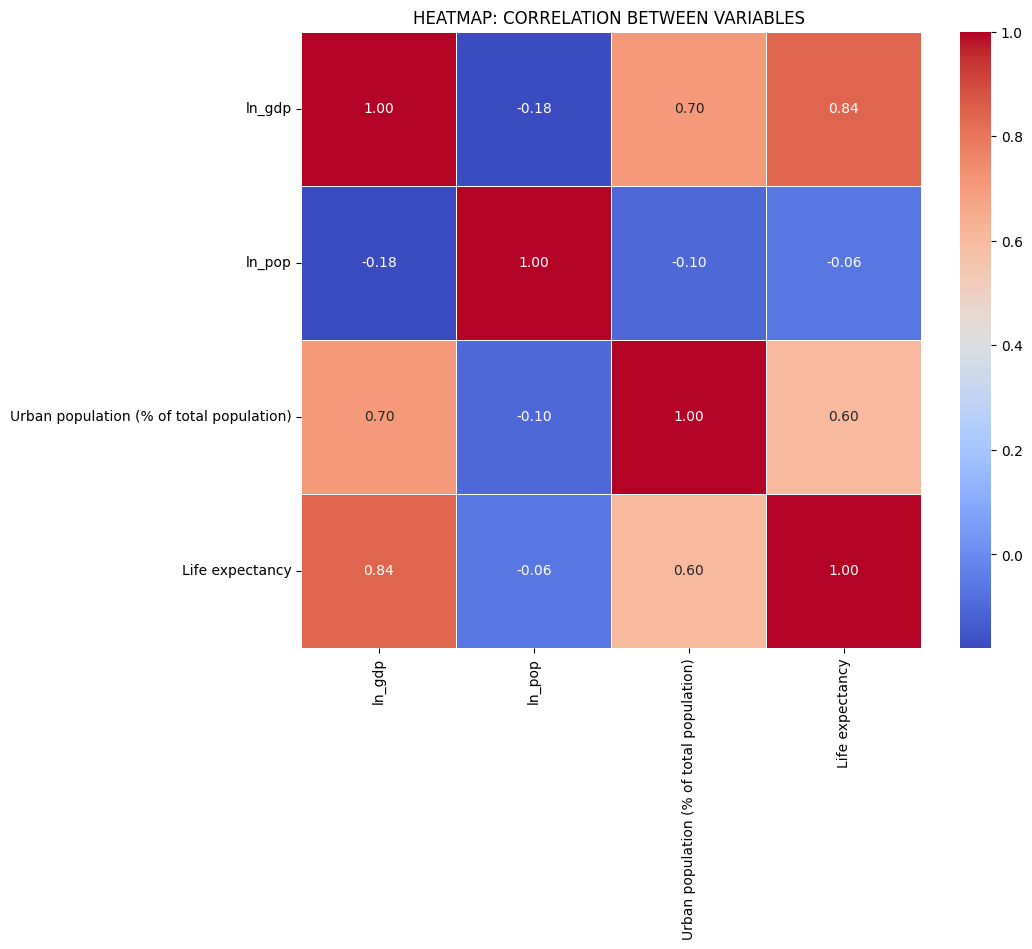

In [ ]:
## HEATMAP ##
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_final[['ln_gdp', 'ln_pop', 'Urban population (% of total population)', 'Life expectancy']].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('HEATMAP: CORRELATION BETWEEN VARIABLES ')
plt.show()

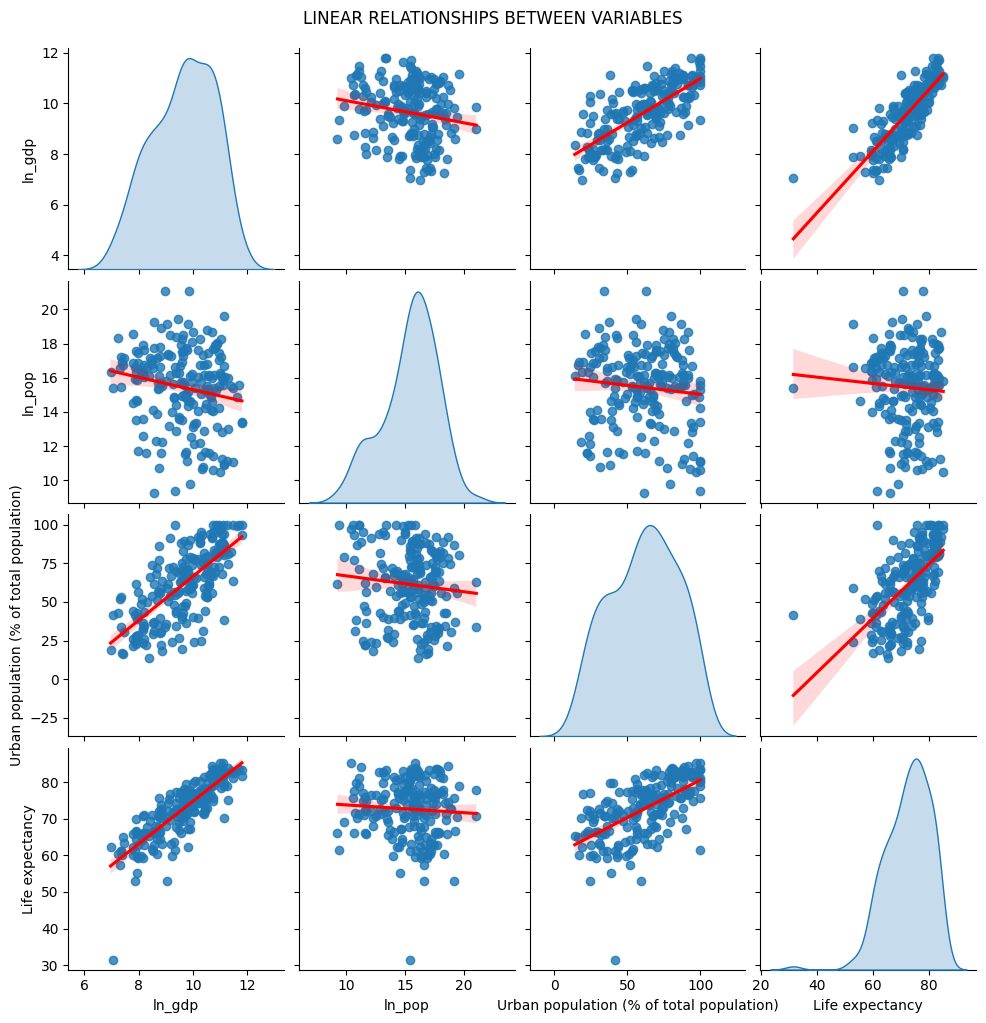

In [ ]:
sns.pairplot(df_final[['ln_gdp', 'ln_pop', 'Urban population (% of total population)', 'Life expectancy']], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('LINEAR RELATIONSHIPS BETWEEN VARIABLES', y=1.02)
plt.show()

In [ ]:
df_final[df_final["GDP per capita"] >26232.075608]

,Entity,Code,Year,GDP per capita,World region according to OWID,Population,Urban population (% of total population),Life expectancy,ln_gdp,ln_pop
3,Andorra,AND,2019,63215.900,Europe,76492,88.539180,84.0980,11.054311,11.244941
5,Antigua and Barbuda,ATG,2019,29651.863,North America,91377,24.708338,77.1681,10.297280,11.422749
6,Argentina,ARG,2019,26629.553,South America,44973469,91.856780,76.8475,10.189777,17.621583
8,Aruba,ABW,2019,39652.633,North America,107089,62.288277,76.0193,10.587913,11.581416
9,Australia,AUS,2019,58048.617,Oceania,25482714,87.301960,83.2412,10.969036,17.053511
...,...,...,...,...,...,...,...,...,...,...
189,United Arab Emirates,ARE,2019,72822.970,Asia,9377855,85.029820,82.5961,11.195787,16.053862
190,United Kingdom,GBR,2019,52515.684,Europe,67110958,82.669945,81.4426,10.868867,18.021858
191,United States,USA,2019,69112.600,North America,337790069,80.130480,78.9160,11.143492,19.637935
192,United States Virgin Islands,VIR,2019,45632.637,North America,89390,95.085750,74.8761,10.728378,11.400764


In [ ]:
df_final["GDP per capita"].describe()

,GDP per capita
count,199.000000
mean,26305.484065
std,26223.851145
min,1057.950100
25%,6337.483350
50%,16761.193000
75%,38237.003500
max,133453.890000


In [ ]:
## THERE ARENT DUPLICATED VALUES ##
df_final.duplicated(subset=["Entity"]).sum()

np.int64(0)

In [ ]:
df_final.columns

Index(['Entity', 'Code', 'Year', 'GDP per capita',
       'World region according to OWID', 'Population',
       'Urban population (% of total population)', 'Life expectancy', 'ln_gdp',
       'ln_pop'],
      dtype='object')

In [ ]:
y = df_final['ln_gdp']
X = df_final[['ln_pop', 'Urban population (% of total population)', 'Life expectancy']]
X = sm.add_constant(X)
modelito = sm.OLS(y, X).fit()

print(modelito.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_gdp   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.32e-63
Time:                        05:58:23   Log-Likelihood:                -158.55
No. Observations:                 199   AIC:                             325.1
Df Residuals:                     195   BIC:                             338.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

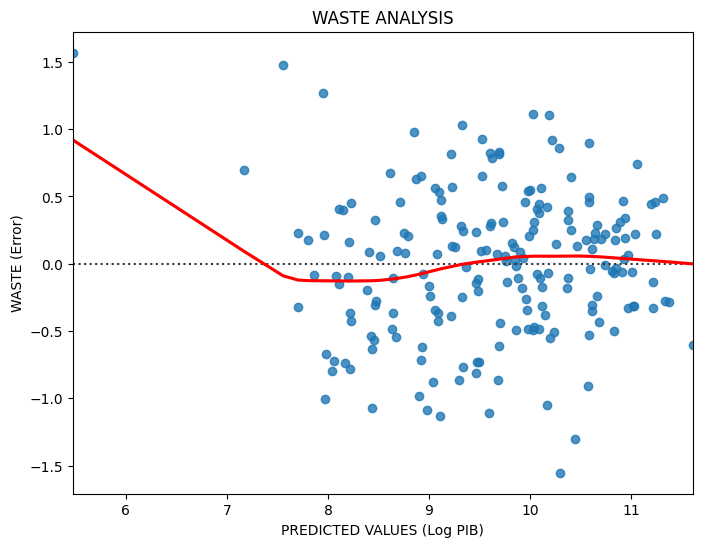

In [ ]:
plt.figure(figsize=(8, 6))
sns.residplot(x=modelito.fittedvalues, y=modelito.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel('PREDICTED VALUES (Log PIB)')
plt.ylabel('WASTE (Error)')
plt.title('WASTE ANALYSIS')
plt.show()

In [ ]:
### OUTLIERS ####



df_final['error'] = abs(modelito.resid)

print("Países extraños:")
print(df_final.sort_values(by='error', ascending=False)[['Entity', 'GDP per capita', 'error']].head(5))

Países extraños:
                       Entity  GDP per capita     error
35   Central African Republic       1145.0956  1.567116
137                 Palestine       6269.8910  1.552117
131                   Nigeria       8361.7870  1.475013
91                     Jordan       9288.5270  1.303071
59                   Eswatini      10099.5860  1.265997


DETECTED THE OUTLIERS


In [ ]:
std_error = modelito.resid.std()


atipicos_extremos = df_final[abs(modelito.resid) > (2 * std_error)]

print("P(Fuera del 95% de confianza):")
print(atipicos_extremos[['Entity', 'GDP per capita', 'error']].sort_values(by='error', ascending=False))

P(Fuera del 95% de confianza):
                       Entity  GDP per capita     error
35   Central African Republic       1145.0956  1.567116
137                 Palestine       6269.8910  1.552117
131                   Nigeria       8361.7870  1.475013
91                     Jordan       9288.5270  1.303071
59                   Eswatini      10099.5860  1.265997
94                   Kiribati       2927.4846  1.131142
71                  Greenland      68534.9450  1.110186
26                     Brunei      80228.1600  1.106878
175                     Syria       4825.4062  1.106611
165           Solomon Islands       2661.6167  1.089016


In [ ]:
df_final[df_final["Entity"]  == "Macao"]

,Entity,Code,Year,GDP per capita,World region according to OWID,Population,Urban population (% of total population),Life expectancy,ln_gdp,ln_pop,error
106,Macao,MAC,2019,133453.89,Asia,670982,100.0,83.2927,11.801511,13.416498,0.486904


In [ ]:
df_final

,Entity,Code,Year,GDP per capita,World region according to OWID,Population,Urban population (% of total population),Life expectancy,ln_gdp,ln_pop,error
0,Afghanistan,AFG,2019,2927.2450,Asia,37856125,25.143726,62.9411,7.981817,17.449303,0.094250
1,Albania,ALB,2019,16761.1930,Europe,2885011,56.763910,79.4669,9.726822,14.875039,0.508239
2,Algeria,DZA,2019,15199.1990,Africa,43294551,72.482450,75.6818,9.628998,17.583537,0.343002
3,Andorra,AND,2019,63215.9000,Europe,76492,88.539180,84.0980,11.054311,11.244941,0.278559
4,Angola,AGO,2019,9648.0110,Africa,32375633,66.663780,63.0511,9.174507,17.292917,0.461730
...,...,...,...,...,...,...,...,...,...,...,...
194,Uzbekistan,UZB,2019,8755.1260,Asia,32964700,50.592010,72.0934,9.077395,17.310948,0.245438
195,Vanuatu,VUT,2019,3512.0720,Oceania,291995,23.502466,70.7834,8.163961,12.584492,0.878679
196,Vietnam,VNM,2019,11628.6140,Asia,97173778,34.623913,74.2113,9.361224,18.392011,0.133338
198,Zambia,ZMB,2019,3591.5642,Africa,18513839,43.489788,62.9145,8.186343,16.734029,0.197668


In [ ]:
df_final[df_final["error"]>1.0].head(10)

,Entity,Code,Year,GDP per capita,World region according to OWID,Population,Urban population (% of total population),Life expectancy,ln_gdp,ln_pop,error
26,Brunei,BRN,2019,80228.1600,Asia,442690,74.792330,75.0490,11.292630,13.000625,1.106878
29,Burundi,BDI,2019,1057.9501,Africa,12255339,18.786179,62.1801,6.964088,16.321472,1.004540
33,Cape Verde,CPV,2019,9111.6300,Africa,514116,71.625430,75.4486,9.117307,13.150204,1.051072
35,Central African Republic,CAF,2019,1145.0956,Africa,4944708,41.780045,31.5302,7.043243,15.413828,1.567116
59,Eswatini,SWZ,2019,10099.5860,Africa,1179885,24.345955,59.8496,9.220250,13.980928,1.265997
71,Greenland,GRL,2019,68534.9450,North America,56109,87.021790,70.2573,11.135099,10.935052,1.110186
91,Jordan,JOR,2019,9288.5270,Asia,10671893,91.515970,76.8645,9.136535,16.183124,1.303071
94,Kiribati,KIR,2019,2927.4846,Oceania,123928,56.284670,65.8663,7.981899,11.727456,1.131142
102,Liberia,LBR,2019,1575.7666,Africa,5043719,52.855263,61.2324,7.362497,15.433654,1.070561
131,Nigeria,NGA,2019,8361.7870,Africa,209485637,58.961117,53.0086,9.031427,19.160166,1.475013


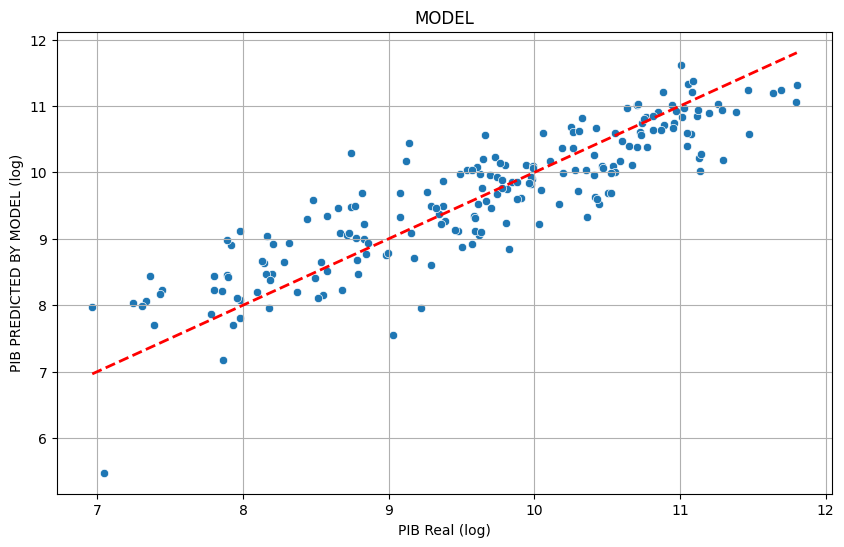

In [ ]:

predicciones = modelito.predict(X)


plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=predicciones)


plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--')

plt.title('MODEL')
plt.xlabel('PIB Real (log)')
plt.ylabel('PIB PREDICTED BY MODEL (log)')
plt.grid(True)
plt.show()

In [ ]:
modelito.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 ln_gdp   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.32e-63
Time:                        06:07:39   Log-Likelihood:                -158.55
No. Observations:                 199   AIC:                             325.1
Df Residuals:                     195   BIC:                             338.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                        2.6925      0.464      5.798      0.000       1.777       3.608
ln_pop                                      -0.0521      0.017     -3.139      0.002      -0.085      -0.019
Urban population (% of total population)     0.0149      0.002      7.129      0.000       0.011       0.019
Life expectancy                              0.0940      0.006     15.512      0.000       0.082       0.106
==============================================================================
Omnibus:                        0.298   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.862   Jarque-Bera (JB):                0.095
Skew:                          -0.009   Prob(JB):                        0.954
Kurtosis:                       3.105   Cond. No.                     1.19e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.19e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""